<a href="https://colab.research.google.com/github/mikhael2104/Kecerdasan-Buatan/blob/main/Jobsheet_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BAGIAN 1: KODE LATIHAN PRAKTIKUM & ANALISIS HASIL**

### 1. Decision Tree (Iris.csv)

Accuracy:  0.933
Hasil Prediksi Bunga Baru: Iris-virginica


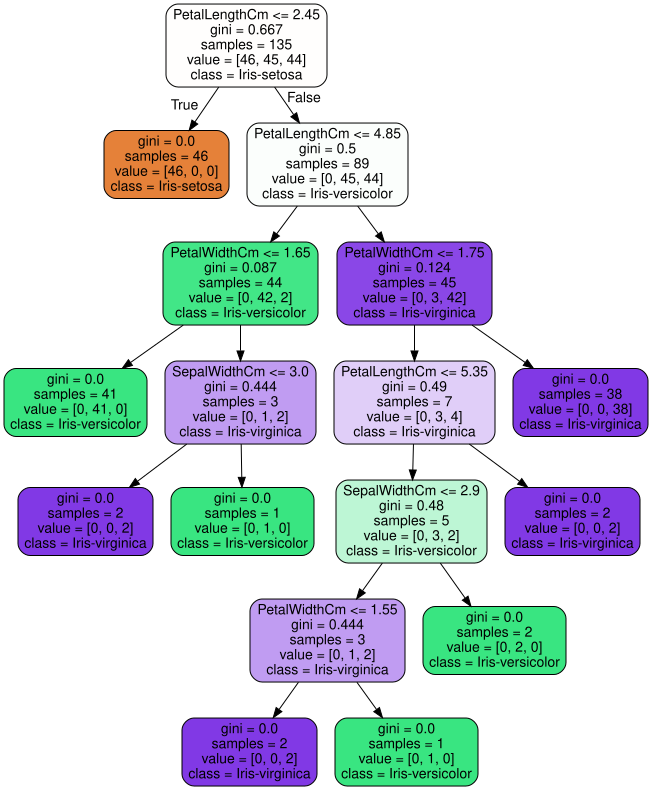

In [16]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import graphviz
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score

# 1. Load Dataset Iris
try:
    iris = pd.read_csv('Iris.csv')
except:
    url_iris = 'https://raw.githubusercontent.com/mwaskom/synthetic-datasets/main/iris.csv'
    iris = pd.read_csv(url_iris)
    iris.rename(columns={
        'sepal_length': 'SepalLengthCm', 'sepal_width': 'SepalWidthCm',
        'petal_length': 'PetalLengthCm', 'petal_width': 'PetalWidthCm',
        'species': 'Species'
    }, inplace=True)

# 2. Hapus kolom Id jika ada
if 'Id' in iris.columns:
    iris.drop('Id', axis=1, inplace=True)

# 3. Memisahkan Atribut (X) dan Label (y)
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = iris['Species']

# 4. Membagi dataset menjadi Data Latih & Data Uji (90:10)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=123
)

# 5. Membuat dan Melatih Model Decision Tree
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

# 6. Evaluasi Akurasi Model
y_pred = tree_model.predict(X_test)
acc_score = round(accuracy_score(y_test, y_pred), 3)
print('Accuracy: ', acc_score)

# 7. Prediksi Sampel Bunga Baru
sample_data = pd.DataFrame(
    [[6.2, 3.4, 5.4, 2.3]],
    columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
)
print('Hasil Prediksi Bunga Baru:', tree_model.predict(sample_data)[0])

# 8. Menampilkan Gambar Diagram Decision Tree Secara Langsung
dot_data = export_graphviz(
    tree_model,
    out_file=None,
    feature_names=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
    class_names=tree_model.classes_,
    rounded=True,
    filled=True
)

graph = graphviz.Source(dot_data)
graph # Memanggil objek graph agar gambar pohon muncul di output Colab

## 2. Linear Regression (Data Dummy Harga Rumah)

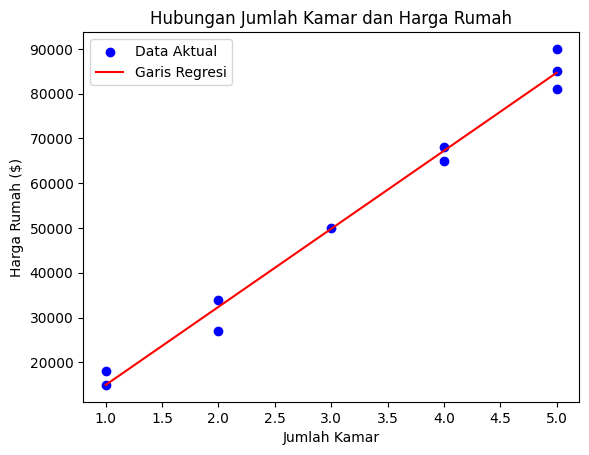

Jumlah kamar: 6
Prediksi harga kamar: $102,110.17

Jumlah kamar: 7
Prediksi harga kamar: $119,542.37

R^2 Score (Training): 0.988


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Data Dummy
bedrooms = np.array([1, 1, 2, 2, 3, 4, 4, 5, 5, 5])
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000, 85000, 90000])

# 2. Reshape & Fit Model
bedrooms_reshape = bedrooms.reshape(-1, 1)
linreg = LinearRegression()
linreg.fit(bedrooms_reshape, house_price)

# 3. Visualisasi Line of Best Fit
plt.scatter(bedrooms, house_price, color='blue', label='Data Aktual')
plt.plot(bedrooms, linreg.predict(bedrooms_reshape), color='red', label='Garis Regresi')
plt.xlabel('Jumlah Kamar')
plt.ylabel('Harga Rumah ($)')
plt.title('Hubungan Jumlah Kamar dan Harga Rumah')
plt.legend()
plt.show()

# 4. Testing & Prediksi Data Baru
X_test = np.array([[6], [7]])
y_pred = linreg.predict(X_test)

for i in range(len(X_test)):
    print(f"Jumlah kamar: {X_test[i][0]}")
    print(f"Prediksi harga kamar: ${y_pred[i]:,.2f}\n")

# Catatan pada modul: linreg.score(X_test, y_pred) pada modul menguji R^2 terhadap nilai prediksi sendiri.
# R^2 Score terhadap data latih:
print("R^2 Score (Training):", round(linreg.score(bedrooms_reshape, house_price), 3))

### 3. Logistic Regression (Social_Network_Ads.csv)

In [10]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# 1. Load Data
df = pd.read_csv('Social_Network_Ads.csv')

# 2. Preprocessing: Drop 'User ID' & One-Hot Encoding
data = df.drop(columns=['User ID'])
data = pd.get_dummies(data, drop_first=True)

# 3. Split Feature & Label
X = data[['Age', 'EstimatedSalary', 'Gender_Male']] # Disesuaikan nama kolom setelah get_dummies
y = data['Purchased']

# 4. Standard Standardization
scaler = StandardScaler()
scaled_X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# 5. Split Train & Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(scaled_X, y, test_size=0.2, random_state=1)

# 6. Fit & Evaluasi Model
model = LogisticRegression()
model.fit(X_train, y_train)

acc = model.score(X_test, y_test)
print('Akurasi Logistic Regression:', round(acc * 100, 2), '%')

Akurasi Logistic Regression: 82.5 %


# **BAGIAN 2: TUGAS PRAKTIKUM JOBSHEET 9**

### Tugas 1 & 3 & 4: Memprediksi Transaksi Konsumen (Decision Tree vs Logistic Regression + Tuning Hyperparameter)

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load Data (Menggunakan delimiter ; jika menggunakan iklan_sosmed.csv)
try:
    df_task1 = pd.read_csv('iklan_sosmed.csv', sep=';')
except:
    df_task1 = pd.read_csv('Social_Network_Ads.csv')

# Drop kolom identifier/ID jika ada
if 'ID' in df_task1.columns: df_task1.drop(columns=['ID'], inplace=True)
if 'User ID' in df_task1.columns: df_task1.drop(columns=['User ID'], inplace=True)

# Rename & One Hot Encoding
df_task1 = pd.get_dummies(df_task1, drop_first=True)

# Tentukan target & fitur
target_col = 'Transaksi' if 'Transaksi' in df_task1.columns else 'Purchased'
X = df_task1.drop(columns=[target_col])
y = df_task1[target_col]

# Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# Split Dataset (80:20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# 1. BASELINE MODEL
# ==========================================
# A. Decision Tree (Baseline)
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
acc_dt_base = accuracy_score(y_test, dt_base.predict(X_test))

# B. Logistic Regression (Baseline)
lr_base = LogisticRegression(random_state=42)
lr_base.fit(X_train, y_train)
acc_lr_base = accuracy_score(y_test, lr_base.predict(X_test))

print("=== AKURASI BASELINE MODEL ===")
print(f"Decision Tree Baseline       : {acc_dt_base * 100:.2f}%")
print(f"Logistic Regression Baseline : {acc_lr_base * 100:.2f}%\n")

# ==========================================
# 2. TUNING HYPERPARAMETER (GridSearchCV)
# ==========================================
# A. Tuning Decision Tree
param_grid_dt = {
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy'],
    'min_samples_split': [2, 5, 10]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
acc_dt_tuned = accuracy_score(y_test, best_dt.predict(X_test))

# B. Tuning Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs']
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
acc_lr_tuned = accuracy_score(y_test, best_lr.predict(X_test))

print("=== AKURASI SETELAH TUNING HYPERPARAMETER ===")
print(f"Decision Tree (Tuned)       : {acc_dt_tuned * 100:.2f}% (Best Params: {grid_dt.best_params_})")
print(f"Logistic Regression (Tuned) : {acc_lr_tuned * 100:.2f}% (Best Params: {grid_lr.best_params_})")

=== AKURASI BASELINE MODEL ===
Decision Tree Baseline       : 82.50%
Logistic Regression Baseline : 88.75%

=== AKURASI SETELAH TUNING HYPERPARAMETER ===
Decision Tree (Tuned)       : 91.25% (Best Params: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 2})
Logistic Regression (Tuned) : 86.25% (Best Params: {'C': 0.01, 'solver': 'liblinear'})


### Tugas 2: Memprediksi Gaji Pegawai Berdasarkan Masa Kerja (Salary_Data.csv / Linear Regression)

=== PERFORMA MODEL LINEAR REGRESSION (GAJI PEGAWAI) ===
R-Squared (R2 Score) : 0.9024
Coeff (Kemiringan)   : 9423.82
Intercept            : 25321.58


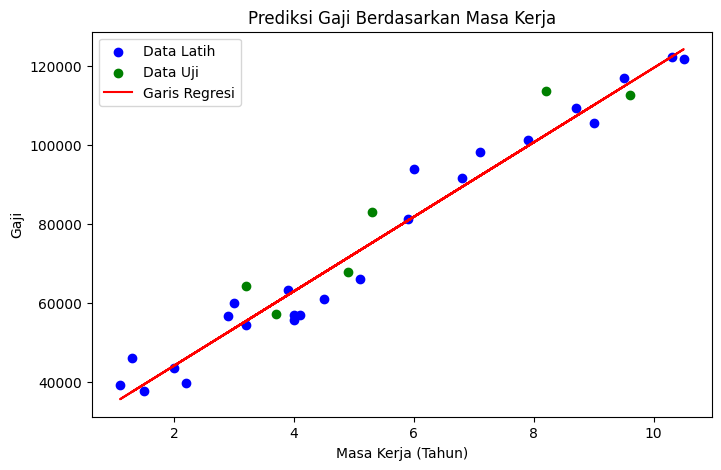

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# 1. Load Dataset Gaji (Salary_Data.csv)
try:
    df_salary = pd.read_csv('Salary_Data.csv')
except:
    df_salary = pd.read_csv('https://raw.githubusercontent.com/SelvaPrabhakaran/datasets/master/SalaryData.csv')

# Pemisahan Fitur & Target
X_salary = df_salary[['YearsExperience']] if 'YearsExperience' in df_salary.columns else df_salary.iloc[:, :-1]
y_salary = df_salary['Salary'] if 'Salary' in df_salary.columns else df_salary.iloc[:, -1]

# 2. Split Train Test Set (80:20)
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_salary, y_salary, test_size=0.2, random_state=42)

# 3. Fit Linear Regression Model
lin_reg_salary = LinearRegression()
lin_reg_salary.fit(X_train_s, y_train_s)

# 4. Prediksi
y_pred_s = lin_reg_salary.predict(X_test_s)

# 5. Evaluasi
r2 = r2_score(y_test_s, y_pred_s)
print("=== PERFORMA MODEL LINEAR REGRESSION (GAJI PEGAWAI) ===")
print(f"R-Squared (R2 Score) : {r2:.4f}")
print(f"Coeff (Kemiringan)   : {lin_reg_salary.coef_[0]:.2f}")
print(f"Intercept            : {lin_reg_salary.intercept_:.2f}")

# 6. Plot Grafik Hasil Regresi
plt.figure(figsize=(8, 5))
plt.scatter(X_train_s, y_train_s, color='blue', label='Data Latih')
plt.scatter(X_test_s, y_test_s, color='green', label='Data Uji')
plt.plot(X_train_s, lin_reg_salary.predict(X_train_s), color='red', label='Garis Regresi')
plt.title('Prediksi Gaji Berdasarkan Masa Kerja')
plt.xlabel('Masa Kerja (Tahun)')
plt.ylabel('Gaji')
plt.legend()
plt.show()